In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

# Create images folder
os.makedirs('images', exist_ok=True)
os.makedirs('dataset', exist_ok=True)

# Set style
sns.set(style="whitegrid")

In [2]:
# Download Apple stock data from Jan 2020 to today
ticker = 'AAPL'
df = yf.download(ticker, start='2020-01-01', end='2024-01-01')

# Keep only the 'Close' column (the final price of the day)
df = df[['Close']]

# Save to CSV for reproducibility (so your repo has data)
df.to_csv('dataset/stock_data.csv')

print(f"Downloaded {df.shape[0]} days of data for {ticker}")
print(df.head())

C:\Users\Abin\AppData\Local\Temp\ipykernel_29476\921907437.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Downloaded 1006 days of data for AAPL
Price           Close
Ticker           AAPL
Date                 
2020-01-02  72.468285
2020-01-03  71.763733
2020-01-06  72.335564
2020-01-07  71.995354
2020-01-08  73.153488


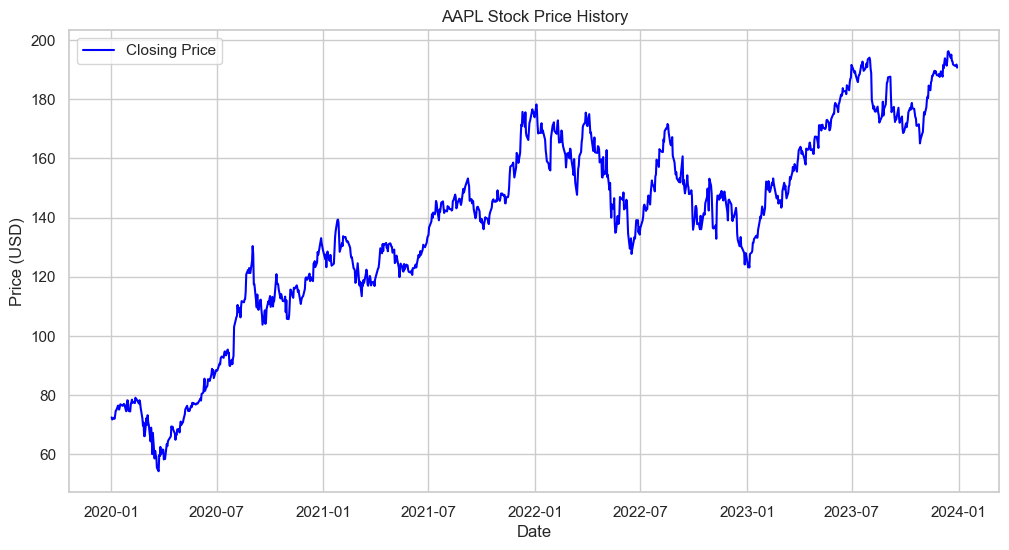

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Closing Price', color='blue')
plt.title(f'{ticker} Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.savefig('images/price_history.png')
plt.show()

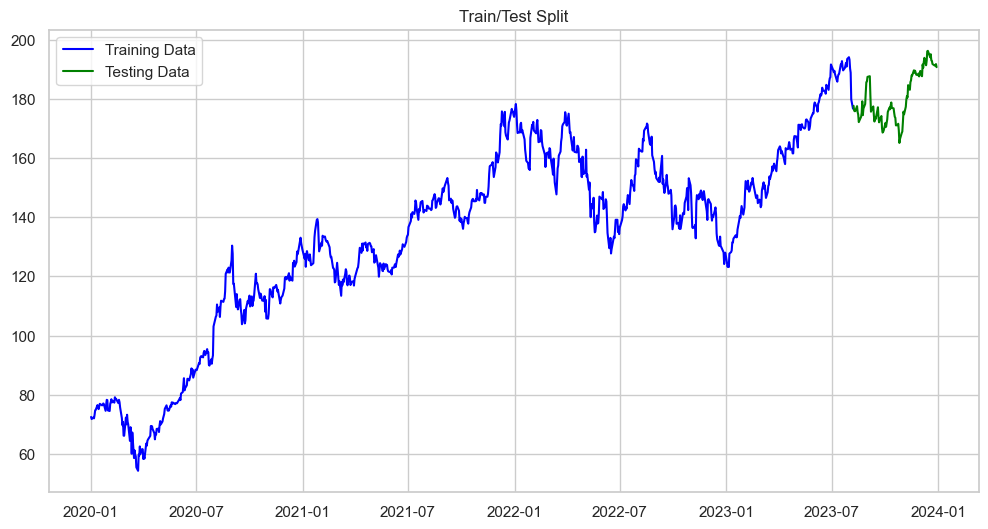

In [4]:
# Split data: 90% for training, 10% for testing
train_size = int(len(df) * 0.9)
train_data, test_data = df[0:train_size], df[train_size:len(df)]

plt.figure(figsize=(12, 6))
plt.plot(train_data, 'blue', label='Training Data')
plt.plot(test_data, 'green', label='Testing Data')
plt.legend()
plt.title('Train/Test Split')
plt.savefig('images/train_test_split.png')
plt.show()

In [5]:
# Initialize and fit the model
# Order (5,1,0) means: use last 5 days to predict, differencing=1, moving average=0
model = ARIMA(train_data, order=(5, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_AAPL   No. Observations:                  905
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2159.766
Date:                Sat, 06 Dec 2025   AIC                           4331.531
Time:                        00:06:23   BIC                           4360.372
Sample:                             0   HQIC                          4342.546
                                - 905                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0483      0.029     -1.667      0.095      -0.105       0.008
ar.L2         -0.0261      0.029     -0.891      0.373      -0.084       0.031
ar.L3         -0.0216      0.032     -0.676      0.4

c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Root Mean Squared Error (RMSE): 8.96
Mean Absolute Error (MAE): 7.07


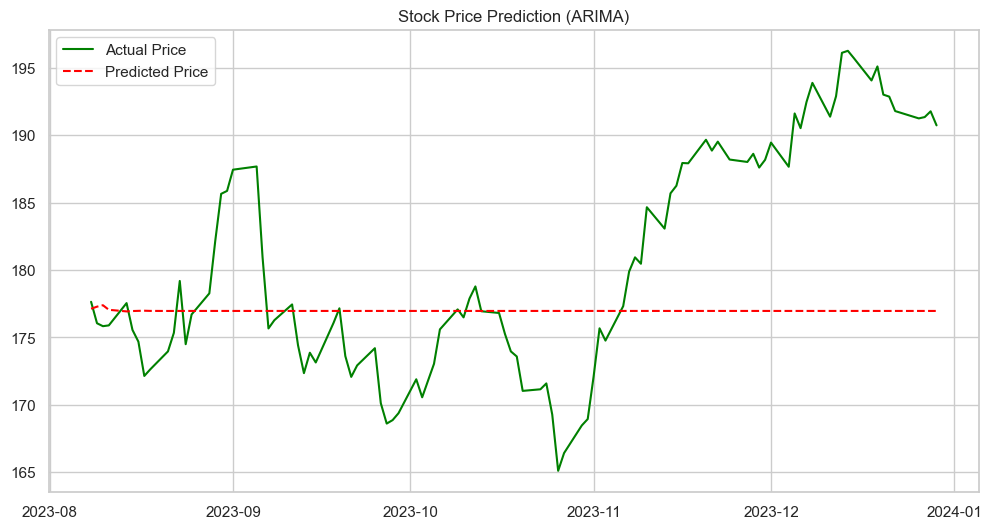

In [7]:
# Forecast on the test set
forecast_result = model_fit.forecast(steps=len(test_data))

# --- THE FIX: Use .values to ignore index mismatch ---
forecast_series = pd.Series(forecast_result.values, index=test_data.index)

# Check if there are still NaNs (just in case)
if forecast_series.isnull().sum() > 0:
    print("Warning: NaNs found in forecast. Filling with previous values.")
    forecast_series.fillna(method='bfill', inplace=True)

# Calculate Error Metrics
rmse = np.sqrt(mean_squared_error(test_data, forecast_series))
mae = mean_absolute_error(test_data, forecast_series)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Plot Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(test_data, label='Actual Price', color='green')
plt.plot(forecast_series, label='Predicted Price', color='red', linestyle='--')
plt.title(f'Stock Price Prediction (ARIMA)')
plt.legend()
plt.savefig('images/forecast_result.png')
plt.show()

c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Abin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is availab

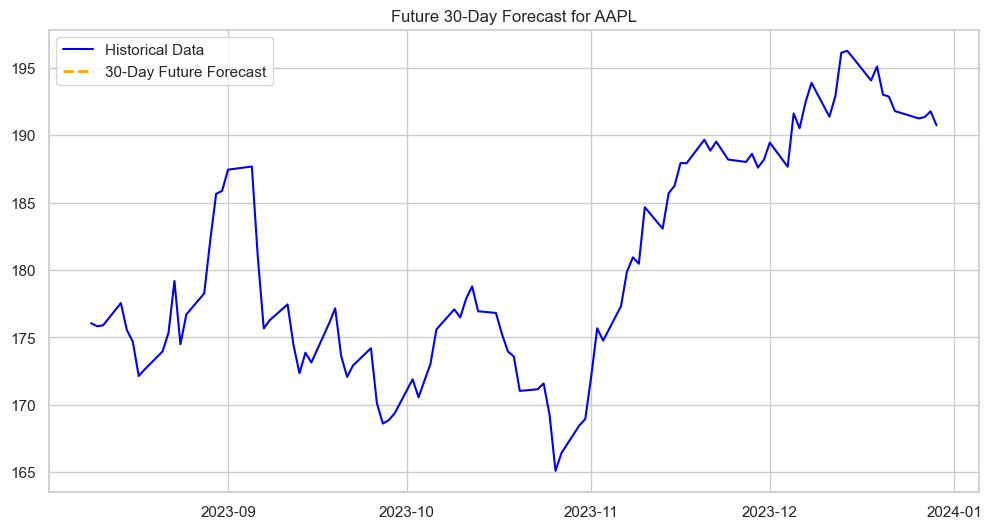

In [8]:
# Refit model on the ENTIRE dataset
full_model = ARIMA(df, order=(5, 1, 0))
full_model_fit = full_model.fit()

# Predict next 30 days
future_steps = 30
future_forecast = full_model_fit.forecast(steps=future_steps)

# Create a date index for the future
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='B')[1:] # 'B' = Business days
future_series = pd.Series(future_forecast, index=future_dates)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Close'].tail(100), label='Historical Data', color='blue') # Show last 100 days
plt.plot(future_series, label='30-Day Future Forecast', color='orange', linestyle='--', linewidth=2)
plt.title(f'Future 30-Day Forecast for {ticker}')
plt.legend()
plt.savefig('images/future_forecast.png')
plt.show()

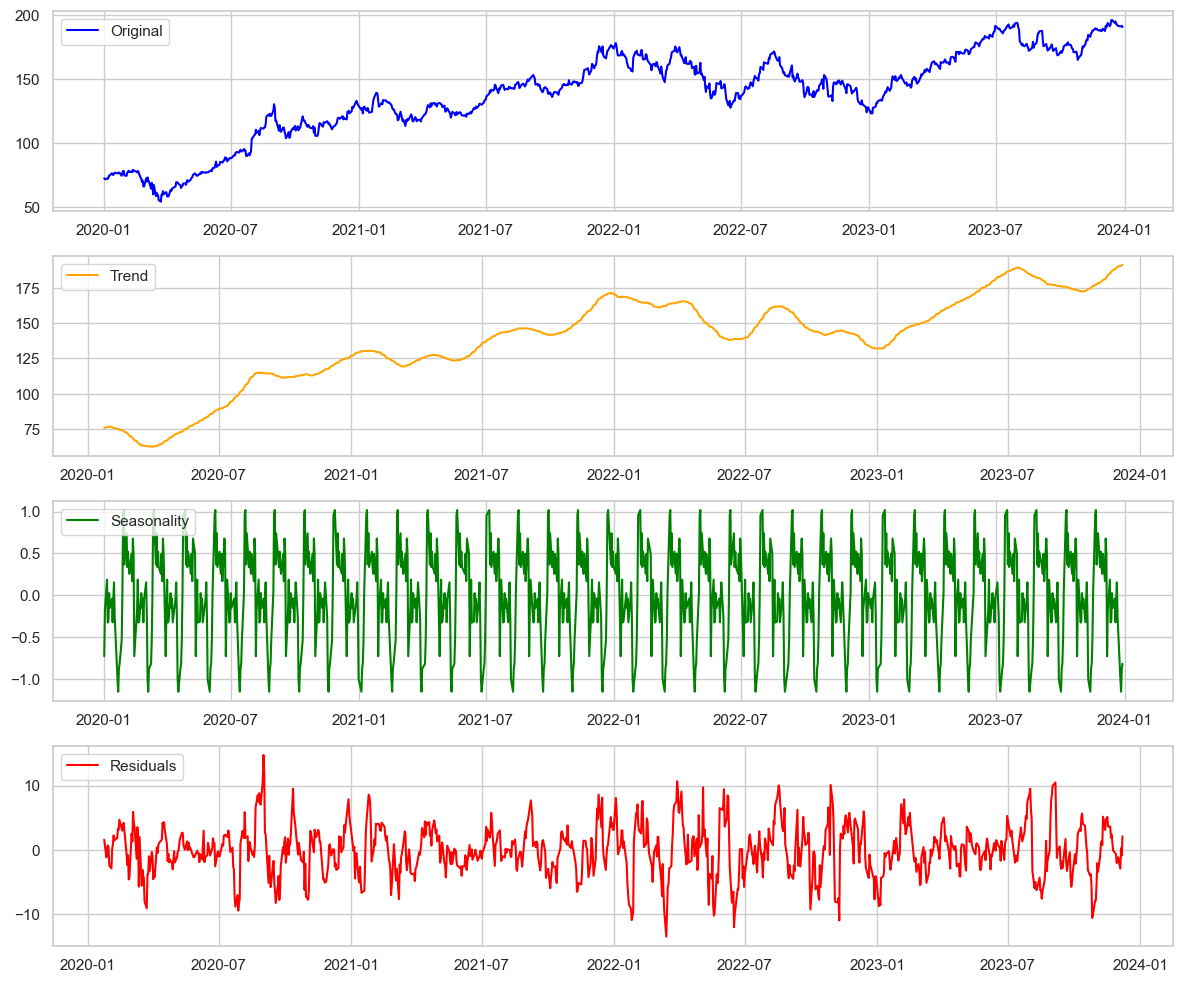

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the Time Series (Period=30 for roughly monthly patterns)
decomposition = seasonal_decompose(df['Close'], model='additive', period=30)

# Plot
plt.figure(figsize=(12, 10))

# 1. Original
plt.subplot(411)
plt.plot(df['Close'], label='Original', color='blue')
plt.legend(loc='upper left')

# 2. Trend
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

# 3. Seasonality
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

# 4. Residuals (Noise)
plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('images/decomposition.png')
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    
    labels = ['ADF Test Statistic', 'p-value', '# Lags Used', '# Observations']
    out = pd.Series(result[0:4], index=labels)
    
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val
        
    print(out)
    
    if result[1] <= 0.05:
        print("Conclusion: Data is Stationary (Good for ARIMA)")
    else:
        print("Conclusion: Data is Non-Stationary (Needs Differencing)")
    print("-" * 30)

# Test raw data
adf_test(df['Close'], "Raw Stock Data")

# Test differenced data (What the model actually sees)
diff_data = df['Close'].diff().dropna()
adf_test(diff_data, "Differenced Data (1st Order)")

Augmented Dickey-Fuller Test: Raw Stock Data
ADF Test Statistic        -1.511951
p-value                    0.527591
# Lags Used                0.000000
# Observations          1005.000000
Critical Value (1%)       -3.436873
Critical Value (5%)       -2.864420
Critical Value (10%)      -2.568304
dtype: float64
Conclusion: Data is Non-Stationary (Needs Differencing)
------------------------------
Augmented Dickey-Fuller Test: Differenced Data (1st Order)
ADF Test Statistic       -32.990254
p-value                    0.000000
# Lags Used                0.000000
# Observations          1004.000000
Critical Value (1%)       -3.436880
Critical Value (5%)       -2.864423
Critical Value (10%)      -2.568305
dtype: float64
Conclusion: Data is Stationary (Good for ARIMA)
------------------------------


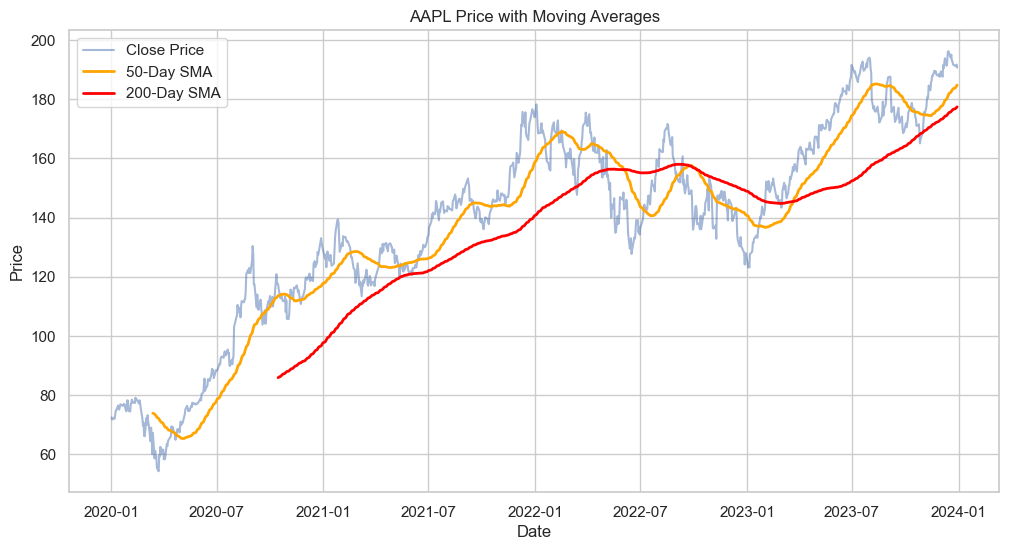

In [11]:
# Calculate Moving Averages
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['SMA_50'], label='50-Day SMA', color='orange', linewidth=2)
plt.plot(df['SMA_200'], label='200-Day SMA', color='red', linewidth=2)

plt.title(f'{ticker} Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.savefig('images/moving_averages.png')
plt.show()